# xLSTM-MIL (Final Structured Notebook)

This notebook is a clean, production-style pipeline for training xLSTM-MIL on real CAMELYON16 features.

## 1) Environment and Imports

In [1]:
!pip -q install timm h5py scikit-learn matplotlib hilbertsfc huggingface_hub pandas
!pip -q install git+https://github.com/NX-AI/xlstm
!test -d /content/vision-lstm || git clone -q https://github.com/NX-AI/vision-lstm /content/vision-lstm

import os
import sys
import re
import math
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

for p in ["/content/vision-lstm", "/content/vision-lstm/src", "/content/xlstm"]:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 2) Download Dataset from Hugging Face

If dataset is gated, make sure your `HF_TOKEN` is stored in Colab Secrets and accessible.

In [2]:
from huggingface_hub import snapshot_download
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
HF_REPO = "kaczmarj/camelyon16-uni"
DATA_ROOT = Path("/content/camelyon16_uni_data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

local_repo = Path(
    snapshot_download(
        repo_id=HF_REPO,
        repo_type="dataset",
        token=HF_TOKEN,
        local_dir=str(DATA_ROOT),
    )
)

EMBED_DIR = local_repo / "embeddings"
PATCH_DIR = local_repo / "patches"
PROCESS_CSV = PATCH_DIR / "process_list_autogen.csv"

print("Repo root:", local_repo)
print("Embeddings dir:", EMBED_DIR)
print("Patches dir:", PATCH_DIR)
print("Manifest:", PROCESS_CSV)
print("#pt:", len(list(EMBED_DIR.glob("*.pt"))))
print("#h5:", len(list(PATCH_DIR.rglob("*.h5"))))


Fetching ... files: 0it [00:00, ?it/s]

Repo root: /content/camelyon16_uni_data
Embeddings dir: /content/camelyon16_uni_data/embeddings
Patches dir: /content/camelyon16_uni_data/patches
Manifest: /content/camelyon16_uni_data/patches/process_list_autogen.csv
#pt: 399
#h5: 399


## 3) Real Dataset Loader with Hilbert Sorting

This loader:
- pairs `.pt` features and `.h5` coords robustly,
- infers labels from slide names (`normal`/`tumor`),
- applies Hilbert sorting,
- keeps full variable-length bags (no truncation/padding), then applies Hilbert sorting.

In [3]:
def _norm_id(s):
    s = str(s).strip().lower()
    s = Path(s).stem
    return re.sub(r"[^a-z0-9]+", "", s)

def infer_label_from_slide_id(slide_id_stem):
    s = slide_id_stem.lower()
    if "tumor" in s:
        return 1
    if "normal" in s:
        return 0
    return None

def _xy2d(n_side, x, y):
    d = 0
    s = n_side // 2
    while s > 0:
        rx = 1 if (x & s) else 0
        ry = 1 if (y & s) else 0
        d += s * s * ((3 * rx) ^ ry)
        if ry == 0:
            if rx == 1:
                x = n_side - 1 - x
                y = n_side - 1 - y
            x, y = y, x
        s //= 2
    return d

def hilbert_indices(coords_np):
    try:
        import hilbertsfc
        mx = int(coords_np.max()) if coords_np.size else 0
        p = max(1, int(math.ceil(math.log2(mx + 1))))
        if hasattr(hilbertsfc, "hilbert_index"):
            return np.array([hilbertsfc.hilbert_index(int(x), int(y), p=p) for x, y in coords_np], dtype=np.int64)
        if hasattr(hilbertsfc, "encode"):
            try:
                return np.array(hilbertsfc.encode(coords_np.astype(np.int64)), dtype=np.int64)
            except Exception:
                return np.array(hilbertsfc.encode(coords_np.astype(np.int64).T), dtype=np.int64)
    except Exception:
        pass
    mx = int(coords_np.max()) if coords_np.size else 0
    p = max(1, int(math.ceil(math.log2(mx + 1))))
    n_side = 1 << p
    return np.array([_xy2d(n_side, int(x), int(y)) for x, y in coords_np.astype(np.int64)], dtype=np.int64)

class WSIFeatureDataset(Dataset):
    def __init__(self, embed_dir, patch_dir, process_csv):
        self.embed_dir = Path(embed_dir)
        self.patch_dir = Path(patch_dir)

        df = pd.read_csv(process_csv)
        if "slide_id" not in df.columns:
            raise ValueError(f"'slide_id' missing. Columns: {list(df.columns)}")

        split_col = next((c for c in ["split", "set", "subset", "partition"] if c in df.columns), None)

        pt_files = sorted(self.embed_dir.glob("*.pt"))
        h5_files = sorted(self.patch_dir.rglob("*.h5"))
        pt_map = {_norm_id(p.stem): p for p in pt_files}
        h5_map = {_norm_id(p.stem): p for p in h5_files}

        self.samples = []
        for _, row in df.iterrows():
            sid_stem = Path(str(row["slide_id"]).strip()).stem
            label = infer_label_from_slide_id(sid_stem)
            if label is None:
                continue

            if split_col is not None and pd.notna(row[split_col]):
                split_name = str(row[split_col]).strip().lower()
            else:
                sid_lower = sid_stem.lower()
                if sid_lower.startswith("test_"):
                    split_name = "test"
                elif sid_lower.startswith(("normal_", "tumor_")):
                    split_name = "train"
                else:
                    split_name = "unknown"

            key = _norm_id(sid_stem)
            pt_path = pt_map.get(key)
            h5_path = h5_map.get(key)
            if pt_path is None or h5_path is None:
                continue
            self.samples.append((sid_stem, pt_path, h5_path, int(label), split_name))

        if len(self.samples) == 0:
            raise RuntimeError("No matched samples found after pairing manifest <-> pt <-> h5")

        self._order_cache = {}

        y = np.array([s[3] for s in self.samples], dtype=np.int64)
        split_counts = pd.Series([s[4] for s in self.samples]).value_counts().to_dict()
        print(f"Loaded {len(self.samples)} slides | normal={(y==0).sum()} tumor={(y==1).sum()}")
        print(f"Split counts: {split_counts}")

    def __len__(self):
        return len(self.samples)

    def indices_for_split(self, split_name):
        target = str(split_name).strip().lower()
        return np.array([i for i, s in enumerate(self.samples) if s[4] == target], dtype=np.int64)

    def _read_coords_h5(self, h5_path, sid=""):
        with h5py.File(h5_path, "r") as f:
            if "coords" in f:
                coords = f["coords"][:]
            else:
                coords = None
                for k in f.keys():
                    arr = f[k][:]
                    if arr.ndim == 2 and arr.shape[1] == 2:
                        coords = arr
                        break
                if coords is None:
                    raise KeyError(f"{sid}: no coordinate dataset (N,2) found")
        return np.asarray(coords, dtype=np.float64)

    def _hilbert_order_for_slide(self, sid, h5_path, n_feats):
        if sid in self._order_cache:
            expected_n, order = self._order_cache[sid]
            if n_feats != expected_n:
                raise ValueError(
                    f"{sid}: features length changed ({n_feats} != cached {expected_n}); possible data mismatch"
                )
            return order

        coords = self._read_coords_h5(h5_path, sid)
        if coords.shape[0] != n_feats:
            raise ValueError(
                f"{sid}: mismatched patch counts feat={n_feats} coord={coords.shape[0]}; refusing to silently truncate"
            )
        if n_feats == 0:
            raise RuntimeError(f"{sid}: empty bag")

        order = np.argsort(hilbert_indices(coords.astype(np.int64, copy=False)))
        self._order_cache[sid] = (n_feats, order)
        return order

    def load_bag_with_coords(self, idx):
        """Same Hilbert ordering as __getitem__, plus patch coordinates for heatmaps."""
        sid, pt_path, h5_path, label, split_name = self.samples[idx]
        feats = torch.load(pt_path, map_location="cpu")
        if isinstance(feats, dict):
            feats = feats["features"] if "features" in feats else next(iter(feats.values()))
        feats = torch.as_tensor(feats, dtype=torch.float32)
        if feats.ndim != 2:
            raise ValueError(f"{sid}: expected 2D features, got {tuple(feats.shape)}")

        order = self._hilbert_order_for_slide(sid, h5_path, feats.shape[0])
        ot = torch.from_numpy(order)
        feats = feats[ot]

        coords_np = self._read_coords_h5(h5_path, sid)
        if coords_np.shape[0] != feats.shape[0]:
            raise ValueError(
                f"{sid}: coord count {coords_np.shape[0]} != feat count {feats.shape[0]} after ordering"
            )
        coords = torch.from_numpy(coords_np)[ot]

        y = torch.tensor([float(label)], dtype=torch.float32)
        return {"slide_id": sid, "features": feats, "coords": coords, "label": y, "split": split_name}

    def __getitem__(self, idx):
        bag = self.load_bag_with_coords(idx)
        return {"slide_id": bag["slide_id"], "features": bag["features"], "label": bag["label"], "split": bag["split"]}

dataset = WSIFeatureDataset(EMBED_DIR, PATCH_DIR, PROCESS_CSV)
FEATURE_DIM = dataset[0]["features"].shape[1]
print("Detected feature dim:", FEATURE_DIM)
ex = dataset[0]
print("Example:", ex["slide_id"], tuple(ex["features"].shape), ex["label"].item())



Loaded 270 slides | normal=159 tumor=111
Split counts: {'train': 270}
Detected feature dim: 1024
Example: normal_001 (2126, 1024) 0.0


## 4) Model Definition (Input Dim from Dataset)

In [4]:
import importlib
import torch.nn.functional as F


def _try_set_mlstm_dropout(mlstm_cfg, p=0.1):
    """Apply dropout-related fields when the installed xlstm exposes them (often none)."""
    applied = []
    for name in (
        "dropout",
        "attention_dropout",
        "attn_dropout",
        "proj_dropout",
        "output_dropout",
        "embedding_dropout",
    ):
        if hasattr(mlstm_cfg, name):
            try:
                setattr(mlstm_cfg, name, float(p))
                applied.append(name)
            except Exception:
                pass
    return applied


def resolve_mlstm_block_factory(
    hidden_dim=256,
    context_length=10_000,
    backend="chunkwise",
    num_heads=4,
    mlstm_dropout=0.1,
):
    candidates = [
        ("xlstm.blocks.mlstm.block", "mLSTMBlock", "mLSTMBlockConfig"),
        ("vislstm.modules.xlstm.blocks.mlstm.block", "mLSTMBlock", "mLSTMBlockConfig"),
        ("vision_lstm.vision_lstm2", "mLSTMBlock", "mLSTMBlockConfig"),
    ]
    errors = []
    for mod_name, cls_name, cfg_name in candidates:
        try:
            mod = importlib.import_module(mod_name)
            if not hasattr(mod, cls_name):
                continue
            mblock_cls = getattr(mod, cls_name)
            cfg_cls = getattr(mod, cfg_name, None)

            if cfg_cls is not None:
                try:
                    cfg = cfg_cls()
                    if hasattr(cfg, "_num_blocks"):
                        cfg._num_blocks = 2
                    if hasattr(cfg, "_block_idx"):
                        cfg._block_idx = 0
                    applied = []
                    if hasattr(cfg, "mlstm"):
                        cfg.mlstm.embedding_dim = int(hidden_dim)
                        cfg.mlstm.context_length = int(context_length)
                        cfg.mlstm.num_heads = int(num_heads)
                        cfg.mlstm.qkv_proj_blocksize = 4
                        cfg.mlstm._num_blocks = getattr(cfg, "_num_blocks", 2)
                        cfg.mlstm.backend = backend
                        applied = _try_set_mlstm_dropout(cfg.mlstm, mlstm_dropout)
                    if hasattr(cfg, "__post_init__"):
                        cfg.__post_init__()
                    _ = mblock_cls(cfg)

                    def factory(dim):
                        c = cfg_cls()
                        if hasattr(c, "_num_blocks"):
                            c._num_blocks = 2
                        if hasattr(c, "_block_idx"):
                            c._block_idx = 0
                        if hasattr(c, "mlstm"):
                            c.mlstm.embedding_dim = int(dim)
                            c.mlstm.context_length = int(context_length)
                            c.mlstm.num_heads = int(num_heads)
                            c.mlstm.qkv_proj_blocksize = 4
                            c.mlstm._num_blocks = getattr(c, "_num_blocks", 2)
                            c.mlstm.backend = backend
                            _try_set_mlstm_dropout(c.mlstm, mlstm_dropout)
                        if hasattr(c, "__post_init__"):
                            c.__post_init__()
                        return mblock_cls(c)

                    print(
                        f"mLSTMBlock resolved: {mod_name} (config constructor, heads={num_heads}, "
                        f"mlstm_dropout_attempt={mlstm_dropout}, applied={applied if applied else 'none'})"
                    )
                    return factory
                except Exception as e:
                    errors.append((mod_name, "config", repr(e)))

            try:
                _ = mblock_cls(hidden_dim)

                def factory(dim):
                    return mblock_cls(dim)

                print(f"mLSTMBlock resolved: {mod_name} (dim constructor; no config dropout)")
                return factory
            except Exception as e:
                errors.append((mod_name, "dim", repr(e)))
        except Exception as e:
            errors.append((mod_name, "import", repr(e)))

    raise RuntimeError(f"Could not construct official mLSTMBlock. errors={errors}")


HIDDEN_DIM = 256
NUM_MLSTM_BLOCKS = 2
NUM_HEADS = 4
CLASSIFIER_DROPOUT = 0.5
INPUT_DROPOUT = 0.1
POST_BLOCK_DROPOUT = 0.1
MLP_DIM = 128
MLSTM_CONTEXT_LENGTH = 16_000  # >= longest bag you will run through the mLSTM

mlstm_block_factory = resolve_mlstm_block_factory(
    hidden_dim=HIDDEN_DIM,
    context_length=MLSTM_CONTEXT_LENGTH,
    backend="chunkwise",
    num_heads=NUM_HEADS,
    mlstm_dropout=0.1,
)


class XLSTMMIL(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim=HIDDEN_DIM,
        num_blocks=NUM_MLSTM_BLOCKS,
        mlp_dim=MLP_DIM,
        dropout=CLASSIFIER_DROPOUT,
        input_dropout=INPUT_DROPOUT,
        post_block_dropout=POST_BLOCK_DROPOUT,
    ):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_dropout = nn.Dropout(input_dropout)
        self.post_block_dropout = float(post_block_dropout)
        self.blocks = nn.ModuleList([mlstm_block_factory(hidden_dim) for _ in range(num_blocks)])
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, 1),
        )

    def forward(self, x):
        x = self.input_dropout(self.input_proj(x))
        for i, b in enumerate(self.blocks):
            if (i + 1) % 2 == 1:
                x = b(x)
            else:
                xr = torch.flip(x, dims=[1])
                xr = b(xr)
                x = torch.flip(xr, dims=[1])
            x = F.dropout(x, p=self.post_block_dropout, training=self.training)
        pooled = x.mean(dim=1)
        return self.cls_head(pooled)


model = XLSTMMIL(in_dim=FEATURE_DIM).to(device)
print(model.__class__.__name__)
if len(model.blocks) > 0:
    print("First mLSTM block:")
    print(model.blocks[0])



mLSTMBlock resolved: xlstm.blocks.mlstm.block (config constructor, heads=4, mlstm_dropout_attempt=0.1, applied=['dropout'])
PFMxLSTMMIL
First mLSTM block:
mLSTMBlock(
  (xlstm_norm): LayerNorm()
  (xlstm): mLSTMLayer(
    (proj_up): Linear(in_features=256, out_features=1024, bias=False)
    (q_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
    (k_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
    (v_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
    (conv1d): CausalConv1d(
      (conv): Conv1d(512, 512, kernel_size=(4,), stride=(1,), padding=(3,), groups=512)
    )
    (conv_act_fn): SiLU()
    (mlstm_cell): mLSTMCell(
      (igate): Linear(in_features=1536, out_features=4, bias=True)
      (fgate): Linear(in_features

## 5) Training (20 Epochs + Class-Imbalance Loss)

In [5]:
from sklearn.model_selection import StratifiedKFold

# Train / in-epoch val: stride cap MAX_SEQ_LEN. Final metrics: MAX_SEQ_EVAL (None = full bag, needs VRAM).
MAX_SEQ_LEN = 12_000
MAX_SEQ_EVAL = 12_000
WEIGHT_DECAY = 1e-4
K_FOLD = 0  # set to 5 for stratified 5-fold on ALL loaded slides (re-trains from scratch each fold)
EARLY_STOP_PATIENCE = 10  # 0 disables early stopping
EARLY_STOP_MIN_DELTA = 0.0


def stride_subsample_hilbert(feats, max_len=None):
    """Hilbert-ordered stride subsample; max_len None keeps full sequence."""
    feats = feats if isinstance(feats, torch.Tensor) else torch.as_tensor(feats, dtype=torch.float32)
    feats = feats.contiguous()
    n = int(feats.shape[0])
    if n == 0:
        return feats
    if max_len is None:
        return feats
    if n <= max_len:
        return feats
    idx = torch.linspace(0, n - 1, steps=max_len).round().long()
    return feats[idx]


def prepare_bag_features(feats, max_len=None):
    if max_len is None:
        max_len = MAX_SEQ_LEN
    return stride_subsample_hilbert(feats, max_len)


all_idx = np.arange(len(dataset), dtype=np.int64)
all_labels = np.array([int(dataset[i]["label"].item()) for i in all_idx], dtype=np.int64)

train_idx = dataset.indices_for_split("train")
val_idx = dataset.indices_for_split("test")

if len(train_idx) == 0:
    raise RuntimeError("No training samples detected. Check manifest split labels or slide naming.")

if len(val_idx) == 0:
    # Typical HF layout: all slides are usable for training; create a stratified eval holdout here.
    train_idx, val_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=SEED,
        stratify=all_labels,
    )

print(f"Train slides: {len(train_idx)} | Eval slides: {len(val_idx)}")


def run_fit(model, train_idx, val_idx):
    train_labels = np.array([int(dataset[i]["label"].item()) for i in train_idx], dtype=np.int64)
    num_pos = int((train_labels == 1).sum())
    num_neg = int((train_labels == 0).sum())
    if num_pos == 0:
        raise RuntimeError("No positive training slides found; cannot compute pos_weight.")
    pos_weight = torch.tensor([num_neg / max(1, num_pos)], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
    EPOCHS = 20
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_losses, val_losses, lr_hist, gpu_peak_mem_gb = [], [], [], []
    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_train = 0.0
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        order = np.random.permutation(train_idx)
        for idx in order:
            bag = dataset[int(idx)]
            feats = prepare_bag_features(bag["features"])

            x = feats.unsqueeze(0).to(device)
            y = bag["label"].to(device)

            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x).squeeze(-1), y)
            loss.backward()
            optimizer.step()
            epoch_train += float(loss.item())

        epoch_train /= len(train_idx)
        train_losses.append(epoch_train)

        model.eval()
        epoch_val = 0.0
        val_true, val_prob = [], []
        with torch.no_grad():
            for idx in val_idx:
                bag = dataset[int(idx)]
                feats = stride_subsample_hilbert(bag["features"], MAX_SEQ_LEN)

                x = feats.unsqueeze(0).to(device)
                y = bag["label"].to(device)
                logits = model(x).squeeze(-1)
                epoch_val += float(criterion(logits, y).item())
                val_true.append(float(y.item()))
                val_prob.append(float(torch.sigmoid(logits).item()))

        epoch_val /= len(val_idx)
        val_losses.append(epoch_val)

        val_true = np.array(val_true, dtype=np.float32)
        val_prob = np.array(val_prob, dtype=np.float32)
        val_pred = (val_prob >= 0.5).astype(np.int64)
        val_acc = float((val_pred == val_true.astype(np.int64)).mean())
        if len(np.unique(val_true)) > 1:
            val_roc_auc = float(roc_auc_score(val_true, val_prob))
            val_pr_auc = float(average_precision_score(val_true, val_prob))
        else:
            val_roc_auc = float("nan")
            val_pr_auc = float("nan")

        lr_now = optimizer.param_groups[0]["lr"]
        lr_hist.append(lr_now)
        peak_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 3) if torch.cuda.is_available() else 0.0
        gpu_peak_mem_gb.append(float(peak_mem))

        if epoch_val < best_val - EARLY_STOP_MIN_DELTA:
            best_val = epoch_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | LR {lr_now:.2e} | Train {epoch_train:.4f} | "
            f"EvalLoss {epoch_val:.4f} | EvalAcc {val_acc:.4f} | EvalROC-AUC {val_roc_auc:.4f} | "
            f"EvalPR-AUC {val_pr_auc:.4f} | PeakGPU {peak_mem:.3f} GB"
        )

        scheduler.step()

        if EARLY_STOP_PATIENCE > 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(
                f"Early stopping at epoch {epoch}/{EPOCHS} "
                f"(no eval loss improvement for {EARLY_STOP_PATIENCE} epochs; "
                f"best eval loss={best_val:.4f})."
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print("Loaded best model weights based on eval loss.")

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "lr_hist": lr_hist,
        "gpu_peak_mem_gb": gpu_peak_mem_gb,
    }
    return model, history, best_val


cv_histories = []
cv_fold_rocs = []

if K_FOLD >= 2:
    print(f"Running {K_FOLD}-fold stratified CV on {len(all_idx)} slides (ignores single split above).")
    print("NOTE: downstream single-split eval cell should be skipped in CV mode.")
    skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=SEED)
    for fold, (tr, va) in enumerate(skf.split(all_idx, all_labels)):
        print(f"--- Fold {fold + 1}/{K_FOLD} ---")
        mdl = XLSTMMIL(in_dim=FEATURE_DIM).to(device)
        mdl, hist, _bv = run_fit(mdl, all_idx[tr], all_idx[va])
        cv_histories.append(hist)

        val_true, val_prob = [], []
        mdl.eval()
        with torch.no_grad():
            for idx in all_idx[va]:
                bag = dataset[int(idx)]
                feats = stride_subsample_hilbert(bag["features"], MAX_SEQ_LEN)
                x = feats.unsqueeze(0).to(device)
                logits = mdl(x).squeeze(-1)
                val_true.append(float(bag["label"].item()))
                val_prob.append(float(torch.sigmoid(logits).item()))
        val_true = np.array(val_true, dtype=np.float32)
        val_prob = np.array(val_prob, dtype=np.float32)
        roc = float(roc_auc_score(val_true, val_prob)) if len(np.unique(val_true)) > 1 else float("nan")
        cv_fold_rocs.append(roc)
        print(f"Fold {fold + 1} holdout ROC-AUC: {roc:.4f}")

    model = mdl
    min_len = min(len(h["train_losses"]) for h in cv_histories)
    train_losses = np.mean([h["train_losses"][:min_len] for h in cv_histories], axis=0).tolist()
    val_losses = np.mean([h["val_losses"][:min_len] for h in cv_histories], axis=0).tolist()
    lr_hist = np.mean([h["lr_hist"][:min_len] for h in cv_histories], axis=0).tolist()
    gpu_peak_mem_gb = np.mean([h["gpu_peak_mem_gb"][:min_len] for h in cv_histories], axis=0).tolist()

    cv_results_df = pd.DataFrame({"fold": np.arange(1, K_FOLD + 1), "roc_auc": cv_fold_rocs})
    print(cv_results_df)
    print(f"CV mean ROC-AUC: {float(np.nanmean(cv_fold_rocs)):.4f}")
else:
    model, hist, _ = run_fit(model, train_idx, val_idx)
    train_losses = hist["train_losses"]
    val_losses = hist["val_losses"]
    lr_hist = hist["lr_hist"]
    gpu_peak_mem_gb = hist["gpu_peak_mem_gb"]


Train slides: 216 | Eval slides: 54
Epoch 01/20 | LR 1.00e-04 | Train 0.8393 | EvalLoss 0.7744 | EvalAcc 0.7593 | EvalROC-AUC 0.7926 | EvalPR-AUC 0.7330 | PeakGPU 29.390 GB
Epoch 02/20 | LR 9.94e-05 | Train 0.7958 | EvalLoss 0.7307 | EvalAcc 0.5741 | EvalROC-AUC 0.7472 | EvalPR-AUC 0.7364 | PeakGPU 29.390 GB
Epoch 03/20 | LR 9.76e-05 | Train 0.7553 | EvalLoss 0.7032 | EvalAcc 0.5926 | EvalROC-AUC 0.7514 | EvalPR-AUC 0.7477 | PeakGPU 29.390 GB
Epoch 04/20 | LR 9.46e-05 | Train 0.7007 | EvalLoss 0.6266 | EvalAcc 0.7778 | EvalROC-AUC 0.8849 | EvalPR-AUC 0.8712 | PeakGPU 29.390 GB
Epoch 05/20 | LR 9.05e-05 | Train 0.6138 | EvalLoss 0.5548 | EvalAcc 0.8333 | EvalROC-AUC 0.8523 | EvalPR-AUC 0.8087 | PeakGPU 29.390 GB
Epoch 06/20 | LR 8.54e-05 | Train 0.5687 | EvalLoss 0.5978 | EvalAcc 0.7407 | EvalROC-AUC 0.8864 | EvalPR-AUC 0.8459 | PeakGPU 29.390 GB
Epoch 07/20 | LR 7.94e-05 | Train 0.4844 | EvalLoss 0.5679 | EvalAcc 0.7407 | EvalROC-AUC 0.8466 | EvalPR-AUC 0.8181 | PeakGPU 29.390 GB
Epoch

## 6) Evaluation and Plots (ROC + PR + Memory + Loss)

In [6]:
def evaluate_model(model, dataset_obj, indices, max_len=None):
    if max_len is None:
        if "MAX_SEQ_EVAL" in globals():
            max_len = globals()["MAX_SEQ_EVAL"]
        else:
            max_len = globals().get("MAX_SEQ_LEN", 12_000)
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for idx in indices:
            bag = dataset_obj[int(idx)]
            feats = stride_subsample_hilbert(bag["features"], max_len)

            x = feats.unsqueeze(0).to(device)
            y = int(bag["label"].item())
            logit = model(x).squeeze().item()
            y_true.append(y)
            y_prob.append(1.0 / (1.0 + math.exp(-logit)))

    y_true = np.array(y_true, dtype=np.int64)
    y_prob = np.array(y_prob, dtype=np.float64)
    y_pred = (y_prob >= 0.5).astype(np.int64)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "avg_precision": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
    }
    return metrics, y_true, y_prob


# Run evaluation
metrics, y_true, y_prob = evaluate_model(model, dataset, val_idx)

eval_split_name = "test" if len(dataset.indices_for_split("test")) > 0 else "validation"
print(f"Final {eval_split_name.title()} Metrics")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Final Validation Metrics
accuracy: 0.8333
precision: 0.7600
recall: 0.8636
roc_auc: 0.8523
avg_precision: 0.8087


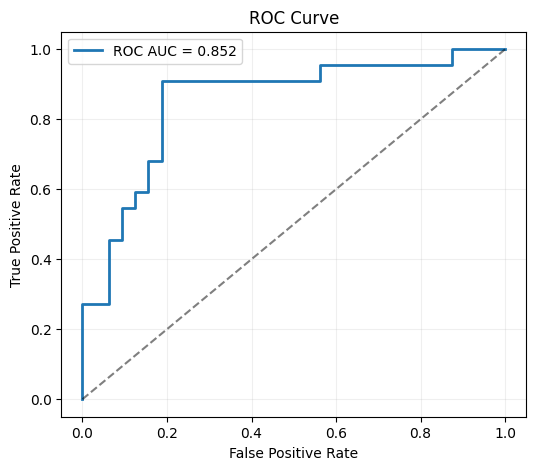

In [7]:
plt.figure(figsize=(6, 5))

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {metrics['roc_auc']:.3f}")
else:
    plt.plot([0, 1], [0, 1], "k--", label="Insufficient class diversity")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

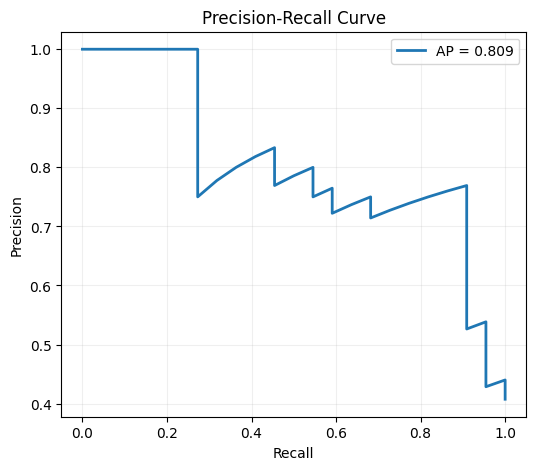

In [8]:
plt.figure(figsize=(6, 5))

if len(np.unique(y_true)) > 1:
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(rec, prec, linewidth=2, label=f"AP = {metrics['avg_precision']:.3f}")
else:
    plt.plot([0, 1], [np.mean(y_true), np.mean(y_true)], "k--",
             label="Insufficient class diversity")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

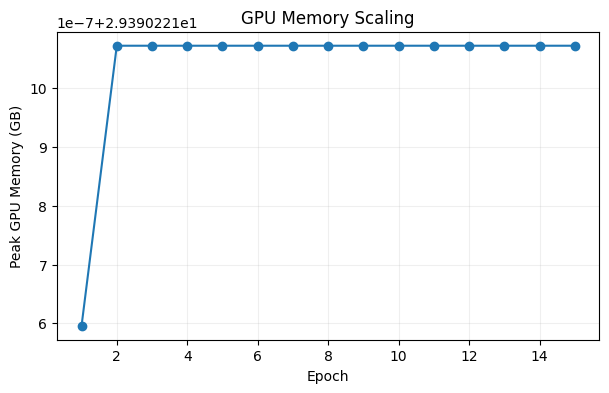

In [9]:
epochs_axis = np.arange(1, len(gpu_peak_mem_gb) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, gpu_peak_mem_gb, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Peak GPU Memory (GB)")
plt.title("GPU Memory Scaling")
plt.grid(alpha=0.2)
plt.show()

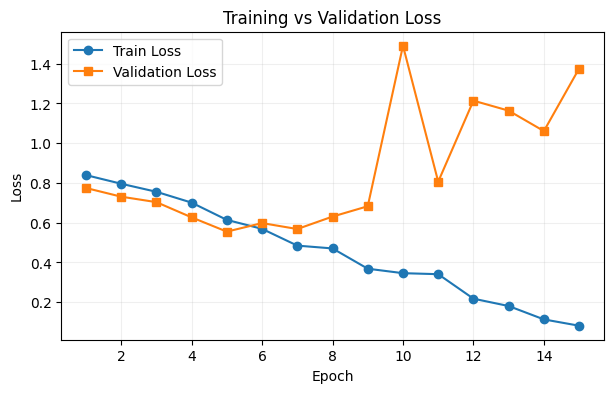

In [10]:
plt.figure(figsize=(7, 4))

plt.plot(epochs_axis, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_axis, val_losses, marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Saliency demo | slide=tumor_075 | patches=4823 | logit=2.6694 | label=1


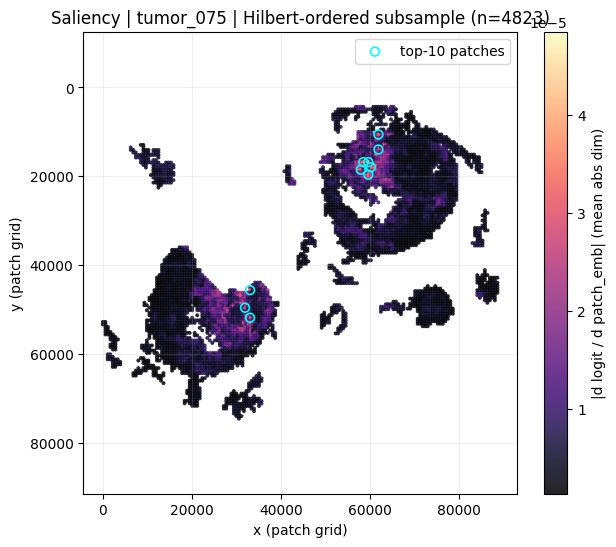

In [11]:
if "MAX_SEQ_LEN" not in globals():
    MAX_SEQ_LEN = 12_000


def subsample_bag_feats_coords(feats, coords, max_len):
    """Match deterministic eval subsampling on both tensors."""
    n = int(feats.shape[0])
    if coords is not None and int(coords.shape[0]) != n:
        raise ValueError("feats/coords length mismatch in subsample_bag_feats_coords")
    if n <= max_len:
        return feats, coords
    idx = torch.linspace(0, n - 1, steps=max_len).round().long()
    if coords is None:
        return feats[idx], None
    return feats[idx], coords[idx]


def patch_input_grad_saliency(model, feats, device, max_len=None):
    """Gradient of scalar logit w.r.t. each patch embedding (input-space saliency)."""
    if max_len is not None:
        feats = subsample_bag_feats_coords(feats, None, max_len)[0]
    model.eval()
    x = feats.unsqueeze(0).to(device).detach().clone().requires_grad_(True)
    logit = model(x).squeeze()
    if logit.ndim != 0:
        logit = logit.reshape(())
    model.zero_grad(set_to_none=True)
    logit.backward()
    g = x.grad.detach()[0]
    importance = g.abs().mean(dim=1).cpu().numpy()
    return importance, float(logit.item())


def plot_slide_saliency_scatter(
    coords_xy,
    importance,
    title="",
    max_points=5000,
    top_k_mark=10,
    s=8,
    cmap="magma",
):
    coords_xy = np.asarray(coords_xy, dtype=np.float64)
    imp = np.asarray(importance, dtype=np.float64)
    if coords_xy.shape[0] != imp.shape[0]:
        raise ValueError(f"coords {coords_xy.shape[0]} vs importance {imp.shape[0]}")

    rng = np.random.default_rng(SEED)
    n = coords_xy.shape[0]
    if n > max_points:
        sub = rng.choice(n, size=max_points, replace=False)
        cx, cy, z = coords_xy[sub, 0], coords_xy[sub, 1], imp[sub]
    else:
        cx, cy, z = coords_xy[:, 0], coords_xy[:, 1], imp

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(cx, cy, c=z, s=s, cmap=cmap, linewidths=0, alpha=0.85)
    plt.colorbar(sc, label="|d logit / d patch_emb| (mean abs dim)")
    if top_k_mark and n >= top_k_mark:
        top = np.argsort(-imp)[:top_k_mark]
        plt.scatter(
            coords_xy[top, 0],
            coords_xy[top, 1],
            s=40,
            facecolors="none",
            edgecolors="cyan",
            linewidths=1.2,
            label=f"top-{top_k_mark} patches",
        )
        plt.legend(loc="best")
    plt.gca().invert_yaxis()
    plt.xlabel("x (patch grid)")
    plt.ylabel("y (patch grid)")
    plt.title(title or "Patch saliency (input gradients)")
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.show()


# --- Demo on one eval slide (change DEMO_IDX to explore) ---
DEMO_IDX = int(val_idx[0]) if "val_idx" in globals() and len(val_idx) > 0 else 0
bag_demo = dataset.load_bag_with_coords(DEMO_IDX)
feats_d, coords_d = subsample_bag_feats_coords(bag_demo["features"], bag_demo["coords"], MAX_SEQ_LEN)
imp, logit0 = patch_input_grad_saliency(model, feats_d, device, max_len=None)
print(
    f"Saliency demo | slide={bag_demo['slide_id']} | patches={len(imp)} | logit={logit0:.4f} | label={bag_demo['label'].item():.0f}"
)
plot_slide_saliency_scatter(
    coords_d.numpy(),
    imp,
    title=f"Saliency | {bag_demo['slide_id']} | Hilbert-ordered subsample (n={len(imp)})",
    max_points=6000,
    top_k_mark=10,
)



## 7) Sequence-Length Memory Scaling Benchmark (Synthetic)

N=  1000 | Peak GPU Mem=0.682 GB
N=  2000 | Peak GPU Mem=1.126 GB
N=  4000 | Peak GPU Mem=2.805 GB
N=  6000 | Peak GPU Mem=5.580 GB
N=  8000 | Peak GPU Mem=9.423 GB


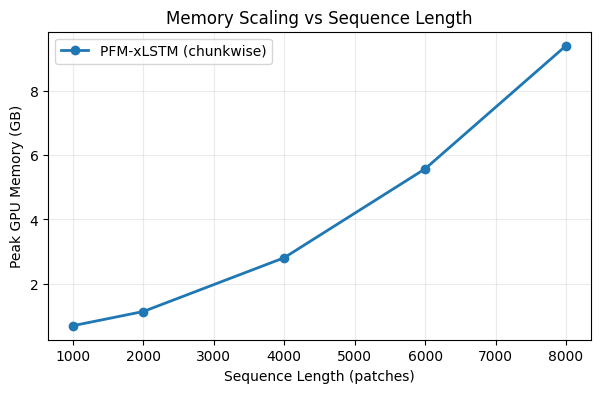

Linear fit: mem_gb = 0.001239 * seq_len + -1.2796 | R^2=0.9573


,seq_len,peak_mem_gb,tokens_per_gb
0,1000,0.682308,1465.614371
1,2000,1.125501,1776.986933
2,4000,2.804653,1426.201545
3,6000,5.579535,1075.358337
4,8000,9.423020,848.984731


In [12]:
@torch.no_grad()
def benchmark_memory_scaling(model, in_dim, seq_lens, dataset_obj=None, index_hint=0, batch_size=1, runs_per_len=2):
    model.eval()
    rows = []
    if not torch.cuda.is_available():
        print("CUDA not available: skipping GPU memory benchmark.")
        return pd.DataFrame(columns=["seq_len", "peak_mem_gb", "tokens_per_gb"])

    ref = None
    if dataset_obj is not None and len(dataset_obj) > 0:
        ref = dataset_obj[int(index_hint) % len(dataset_obj)]["features"]
        ref = ref.to(device)

    for n in seq_lens:
        peak_vals = []
        for _ in range(runs_per_len):
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats(device)

            if ref is None:
                x = torch.randn(batch_size, n, in_dim, device=device)
            else:
                m = int(ref.shape[0])
                if m >= n:
                    idx = torch.randperm(m, device=ref.device)[:n]
                    base = ref[idx]
                else:
                    reps = int(math.ceil(n / m))
                    base = ref.repeat(reps, 1)[:n]
                # Tiny jitter avoids exact repeated rows while preserving realistic magnitudes.
                base = base + 0.01 * torch.randn_like(base)
                x = base.unsqueeze(0).repeat(batch_size, 1, 1)

            _ = model(x)
            torch.cuda.synchronize(device)
            peak_gb = torch.cuda.max_memory_allocated(device) / (1024 ** 3)
            peak_vals.append(float(peak_gb))
            del x

        peak_mem_gb = float(np.mean(peak_vals))
        rows.append(
            {
                "seq_len": int(n),
                "peak_mem_gb": peak_mem_gb,
                "tokens_per_gb": (n / peak_mem_gb) if peak_mem_gb > 0 else float("nan"),
            }
        )
        print(f"N={n:6d} | Peak GPU Mem={peak_mem_gb:.3f} GB")

    return pd.DataFrame(rows)


SEQ_BENCH = [1000, 2000, 4000, 6000, 8000]
bench_idx = int(train_idx[0]) if "train_idx" in globals() and len(train_idx) > 0 else 0
mem_df = benchmark_memory_scaling(model, FEATURE_DIM, SEQ_BENCH, dataset_obj=dataset, index_hint=bench_idx, batch_size=1, runs_per_len=2)

if not mem_df.empty:
    plt.figure(figsize=(7, 4))
    plt.plot(mem_df["seq_len"], mem_df["peak_mem_gb"], marker="o", linewidth=2, label="xLSTM-MIL (chunkwise)")
    plt.xlabel("Sequence Length (patches)")
    plt.ylabel("Peak GPU Memory (GB)")
    plt.title("Memory Scaling vs Sequence Length")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    x = mem_df["seq_len"].to_numpy(dtype=np.float64)
    y = mem_df["peak_mem_gb"].to_numpy(dtype=np.float64)
    slope, intercept = np.polyfit(x, y, 1)
    r2 = 1.0 - (np.sum((y - (slope * x + intercept)) ** 2) / np.sum((y - y.mean()) ** 2))
    print(f"Linear fit: mem_gb = {slope:.6f} * seq_len + {intercept:.4f} | R^2={r2:.4f}")
    display(mem_df)

